In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [ ]:
df = pd.read_excel("/content/Electronic Sales Data_All Transaksi.xlsx", sheet_name="All")
df.head()


,Channel,Qty,Harga,Total_Penjualan,Nama_Customer,Customer_Provinsi,Customer_Segmen,Nama_Produk
0,Offline,15,12389188,185837820,UD Anggraini Permadi (Persero) Tbk,Sumatera Utara,Swasta,Smartphone
1,Online,11,12456910,137026010,UD Purwanti (Persero) Tbk,Sumatera Utara,Swasta,Smartphone
2,Online,17,2633245,44765165,CV Zulaika Pranowo (Persero) Tbk,Sumatera Utara,Swasta,Monitor
3,Offline,20,14616716,292334320,CV Zulaika Pranowo (Persero) Tbk,Sumatera Utara,Swasta,Smartphone
4,Offline,6,9792285,58753710,CV Zulaika Pranowo (Persero) Tbk,Sumatera Utara,Swasta,Laptop


In [ ]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Channel            969 non-null    object
 1   Qty                969 non-null    int64 
 2   Harga              969 non-null    int64 
 3   Total_Penjualan    969 non-null    int64 
 4   Nama_Customer      969 non-null    object
 5   Customer_Provinsi  969 non-null    object
 6   Customer_Segmen    969 non-null    object
 7   Nama_Produk        969 non-null    object
dtypes: int64(3), object(5)
memory usage: 60.7+ KB


# Produk Tier

In [ ]:
high_value_products = ["Tablet", "Pinter"]

df["Product_Tier"] = np.where(
    df["Nama_Produk"].isin(high_value_products),
    "High","Low"
)

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format
df.groupby("Product_Tier")["Total_Penjualan"].mean()

,Total_Penjualan
Product_Tier,
High,"88,693,543"
Low,"82,086,845"


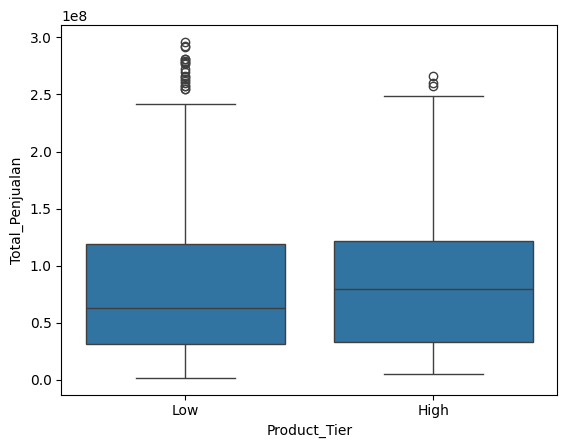

In [ ]:
sns.boxplot(x="Product_Tier", y="Total_Penjualan", data=df)
plt.show()


In [ ]:
from scipy import stats
import numpy as np
pd.options.display.float_format = '{:,.0f}'.format

data = df["Total_Penjualan"].dropna()
z = (data - np.mean(data)) / np.std(data, ddof=1)
stats.kstest(z, 'norm')


KstestResult(statistic=np.float64(0.11696479890996642), pvalue=np.float64(5.2460258533815116e-12), statistic_location=np.float64(-0.35343981590542484), statistic_sign=np.int8(1))

In [ ]:
high = df[df["Product_Tier"]=="High"]["Total_Penjualan"]
low = df[df["Product_Tier"]=="Low"]["Total_Penjualan"]

u_stat, p_value = stats.mannwhitneyu(high, low, alternative='two-sided')

print("U-statistic:", u_stat)
print("P-value:", p_value)

U-statistic: 81980.0
P-value: 0.1077169744241711


In [ ]:
import statsmodels.api as sm

model = smf.ols(
    "np.log(Total_Penjualan) ~ C(Product_Tier) + C(Channel) + Qty",
    data=df
).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     np.log(Total_Penjualan)   R-squared:                       0.545
Model:                                 OLS   Adj. R-squared:                  0.543
Method:                      Least Squares   F-statistic:                     384.7
Date:                     Sun, 22 Feb 2026   Prob (F-statistic):          2.61e-164
Time:                             08:21:23   Log-Likelihood:                -968.09
No. Observations:                      969   AIC:                             1944.
Df Residuals:                          965   BIC:                             1964.
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [ ]:
(df["Product_Tier"].value_counts(normalize=True) * 100).round(2)

,proportion
Product_Tier,
Low,80
High,20


# Segment Analysis

In [ ]:
import pandas as pd
import scipy.stats as stats

# lihat daftar segmen unik
print(df["Customer_Segmen"].unique())

# ambil data qty per segmen
groups = [
    group["Total_Penjualan"].values
    for name, group in df.groupby("Customer_Segmen")
]

# kruskal-wallis test
stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("P-value:", p_value)


['Swasta' 'UMKM' 'Individu' 'Pemerintah']
Kruskal-Wallis Statistic: 0.3034660220382648
P-value: 0.9593753025225075


In [ ]:
# buat contingency table
contingency_table = pd.crosstab(
    df["Customer_Segmen"],
    df["Product_Tier"]
)

print(contingency_table)

# chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)


Product_Tier     High  Low
Customer_Segmen           
Individu           44  165
Pemerintah         35  124
Swasta             71  294
UMKM               48  188
Chi-square statistic: 0.510677259252289
P-value: 0.9165394801558561
Degrees of freedom: 3


# Province Analysis

In [ ]:
from scipy.stats import kruskal

groups = [
    group["Total_Penjualan"].values
    for name, group in df.groupby("Customer_Provinsi")
]

stat, p = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("P-value:", p)


Kruskal-Wallis Statistic: 6.4541731091867405
P-value: 0.37427945651351147


In [ ]:
import statsmodels.formula.api as smf
import numpy as np

model = smf.ols(
    "np.log(Total_Penjualan) ~ C(Customer_Provinsi) + Qty",
    data=df
).fit()

print(model.summary())


                               OLS Regression Results                              
Dep. Variable:     np.log(Total_Penjualan)   R-squared:                       0.546
Model:                                 OLS   Adj. R-squared:                  0.543
Method:                      Least Squares   F-statistic:                     165.2
Date:                     Sun, 22 Feb 2026   Prob (F-statistic):          4.45e-160
Time:                             08:22:23   Log-Likelihood:                -966.42
No. Observations:                      969   AIC:                             1949.
Df Residuals:                          961   BIC:                             1988.
Df Model:                                7                                         
Covariance Type:                 nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

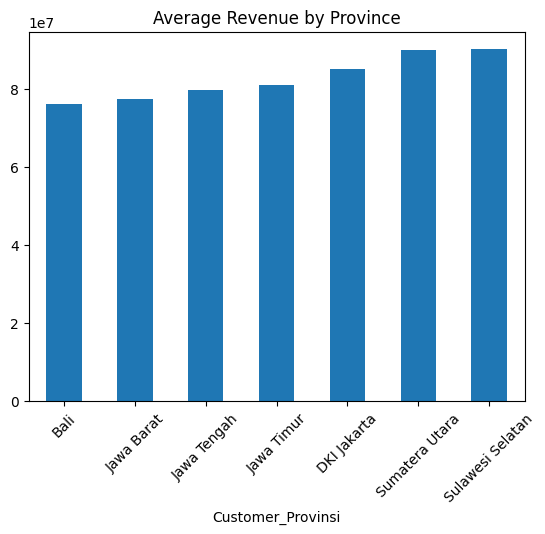

In [ ]:
import matplotlib.pyplot as plt

avg_rev = df.groupby("Customer_Provinsi")["Total_Penjualan"].mean().sort_values()

plt.figure()
avg_rev.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Average Revenue by Province")
plt.show()


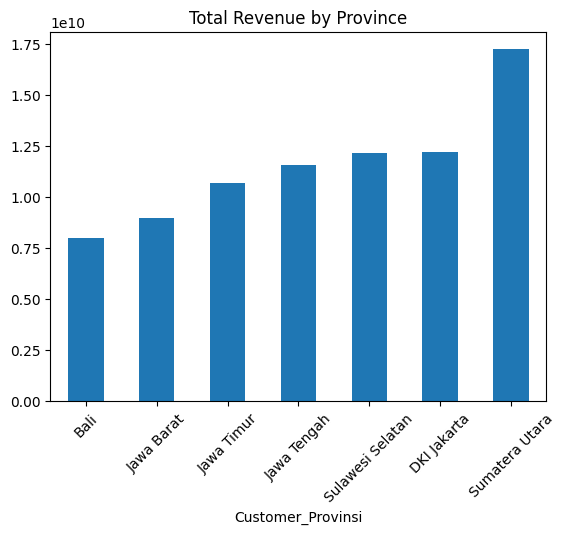

In [ ]:
total_rev = df.groupby("Customer_Provinsi")["Total_Penjualan"].sum().sort_values()

plt.figure()
total_rev.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Total Revenue by Province")
plt.show()


# Growth Trend


In [ ]:
df_ts = pd.read_excel("/content/Electronic Sales Data_All Transaksi.xlsx", sheet_name="Revenue Bulanan")
df_ts.head()

,Month,Revenue
0,2024-01-01,1601557485
1,2024-02-01,1823794360
2,2024-03-01,3839926335
3,2024-04-01,3628513259
4,2024-05-01,2994362207


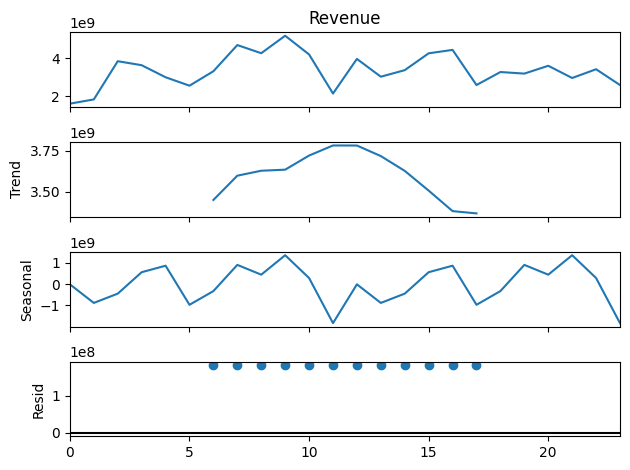

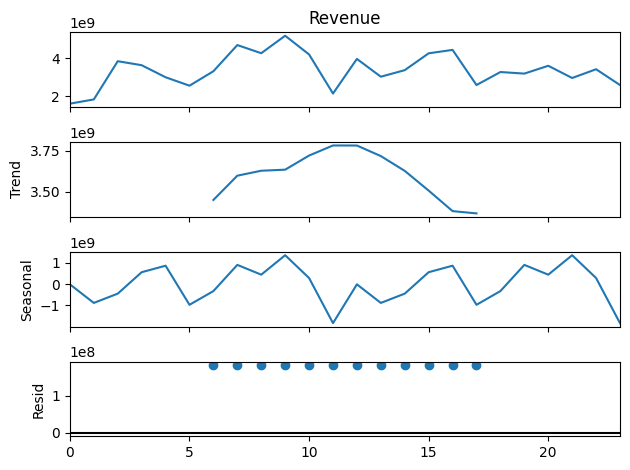

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_ts["Revenue"], model="additive", period=12)
result.plot()

In [ ]:
seasonal = result.seasonal

In [ ]:
seasonal = result.seasonal
seasonal.index = df_ts['Month']
seasonal_monthly = seasonal.groupby(seasonal.index.month).mean()

In [ ]:
import pandas as pd

seasonal_class = pd.DataFrame({
    "bulan": seasonal_monthly.index,
    "nilai_seasonal": seasonal_monthly.values,
})

seasonal_class["kategori"] = seasonal_class["nilai_seasonal"].apply(
    lambda x: "di atas rata-rata" if x > 0 else "di bawah rata-rata"
)

seasonal_class

In [ ]:
seasonal_class["nama_bulan"] = seasonal_class["bulan"].map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "Mei", 6: "Jun", 7: "Jul", 8: "Agt",
    9: "Sep", 10: "Okt", 11: "Nov", 12: "Des"
})

seasonal_class = seasonal_class[["bulan", "nama_bulan", "nilai_seasonal", "kategori"]]
seasonal_class

,bulan,nama_bulan,nilai_seasonal,kategori
0,1,Jan,"-5,690,792",di bawah rata-rata
1,2,Feb,"-879,765,764",di bawah rata-rata
2,3,Mar,"-443,475,246",di bawah rata-rata
3,4,Apr,"564,892,389",di atas rata-rata
4,5,Mei,"871,225,945",di atas rata-rata
5,6,Jun,"-968,215,288",di bawah rata-rata
6,7,Jul,"-322,689,228",di bawah rata-rata
7,8,Agt,"909,720,939",di atas rata-rata
8,9,Sep,"449,102,337",di atas rata-rata
9,10,Okt,"1,364,499,178",di atas rata-rata


In [ ]:
high_season = seasonal_class[seasonal_class["nilai_seasonal"] > 0]
low_season = seasonal_class[seasonal_class["nilai_seasonal"] < 0]

print("High season:")
print(high_season[["nama_bulan", "nilai_seasonal"]])

print("\nLow season:")
print(low_season[["nama_bulan", "nilai_seasonal"]])

High season:
   nama_bulan  nilai_seasonal
3         Apr     564,892,389
4         Mei     871,225,945
7         Agt     909,720,939
8         Sep     449,102,337
9         Okt   1,364,499,178
10        Nov     291,355,237

Low season:
   nama_bulan  nilai_seasonal
0         Jan      -5,690,792
1         Feb    -879,765,764
2         Mar    -443,475,246
5         Jun    -968,215,288
6         Jul    -322,689,228
11        Des  -1,830,959,707


In [ ]:
high = ", ".join(high_season["nama_bulan"])
low = ", ".join(low_season["nama_bulan"])

print(f"Bulan dengan revenue di atas rata-rata: {high}")
print(f"Bulan dengan revenue di bawah rata-rata: {low}")

Bulan dengan revenue di atas rata-rata: Apr, Mei, Agt, Sep, Okt, Nov
Bulan dengan revenue di bawah rata-rata: Jan, Feb, Mar, Jun, Jul, Des
